:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`convolve_large_arrays.ipynb`**!

:::


# Convolve Large Arrays

## Batching Convolutions

Operations that can be vectorized—such as convolving multiple arrays—can benefit significantly from GPU acceleration. However, when the input arrays are large, full vectorization may cause excessive memory allocation on the GPU, potentially leading to runtime errors or causing the operation to fall back to CPU execution, see this [related issue](https://github.com/flatironinstitute/nemos/issues/345) for more details.

By default, NeMoS vectorizes convolutions over all dimensions except the sample axis. On large arrays, this default behavior may exceed the GPU’s memory capacity. To mitigate this, you can control the memory footprint by specifying batch sizes for the convolution along the following dimensions:

- **`batch_size_channels`**: batches the operation over time series channels.

- **`batch_size_basis`**: batches over basis kernels.

- **`batch_size_samples`**: performs the convolution in sliding windows over time, with the given sample size per batch.

Use these keyword arguments inside `conv_kwargs` when initializing a convolutional basis to enable batched processing.

<figure markdown>
<!-- note that the src here has an extra ../ compared to other images, necessary when specifying path directly in html -->
<img src="../_static/convolve_batching_scheme.svg" style="width: 100%", alt="Batched dimensions scheme."/>
<figcaption>Schematic of the batched dimensions.</figcaption>
</figure>

:::{note} CPU vs GPU memory allocation

On the CPU, the vectorization process does not result in excessive memory allocation. As a result, specifying batch sizes has little to no effect on the overall memory footprint.

On the GPU, however, specifying smaller batch sizes **significantly reduces** the memory allocated during computation by limiting the size of intermediate tensors.
:::

### Example

In [1]:
import numpy as np
import nemos as nmo

# vectorize over 5 channels and 2 basis
batch_size_dict = dict(
    batch_size_samples=2000,
    batch_size_channels=5,
    batch_size_basis=2
)

# define the arrays
n_samples, n_channels, n_basis, window_size = 10_000, 10, 8, 100

time_series = np.random.randn(n_samples, n_channels)

# define a basis in conv mode sepecifying the batch sizes
basis = nmo.basis.RaisedCosineLogConv(n_basis, window_size, conv_kwargs=batch_size_dict)

# performe the convolution as usual
out = basis.compute_features(time_series)

# note that this works for n-dimensional array (not only 2-dimensional arrays)
# here an example with a 3D array:
out2 = basis.compute_features(
    np.random.randn(n_samples, n_channels, 2)
)

## Choosing between direct and FFT convolution with `use_fft`

Besides memory, the other lever on large arrays is compute time. A direct convolution costs time proportional to the window size for every output sample, so long kernels make it expensive; an FFT convolution computes the same result in the frequency domain at a cost nearly independent of the window size. The `use_fft` convolution keyword controls which backend runs: `True` or `False` forces the choice, while the default `None` resolves it per input array — on CPU, FFT is selected when the window is long relative to the logarithm of the convolution block, and on other devices (or while tracing under `jax.jit`, where the device cannot be inspected) the direct backend is used.

:::{note} Why the automatic selection only runs on CPU

On the GPU, `use_fft=None` always dispatches the direct path. There, XLA lowers the convolution to its own GPU kernels and selects the algorithm itself, so a Python-side FFT-vs-direct rule would only second-guess the compiler. An explicit `use_fft=True` is still honored on the GPU.
:::

In [2]:
n_samples, window_size, n_basis = 500_000, 256, 8
x = np.random.randn(n_samples)

# default: pick the backend automatically per input array
basis = nmo.basis.RaisedCosineLogConv(n_basis, window_size)
X_auto = basis.compute_features(x)

# force the FFT backend through conv_kwargs (use_fft=False forces direct)
basis_fft = nmo.basis.RaisedCosineLogConv(
    n_basis, window_size, conv_kwargs={"use_fft": True}
)
X_fft = basis_fft.compute_features(x)

The two backends produce the same design matrix up to floating-point round-off; only the speed differs. The heatmap below times both on the CPU across window sizes and recording lengths (white marks where they are equally fast), and overlays the boundary where the automatic selection switches to FFT.

In [3]:
import jax

jax.config.update("jax_enable_x64", True)

[Text(1, 0.0, 'FFT faster'),
 Text(1, 0.5, 'equal'),
 Text(1, 1.0, 'direct faster')]

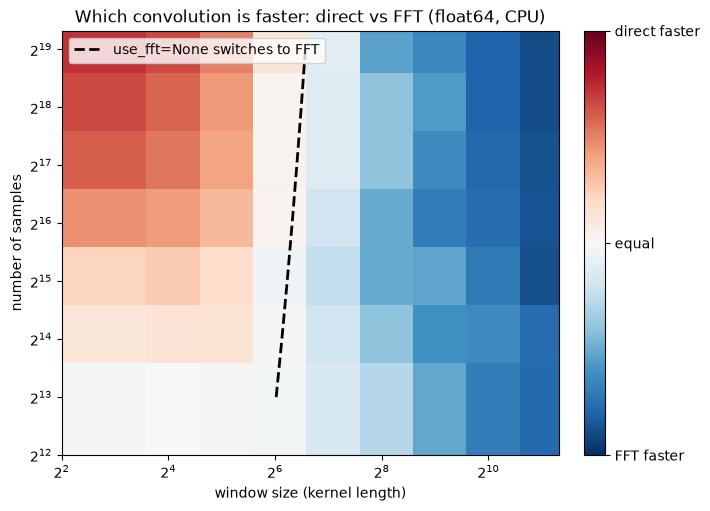

In [4]:
import time

import matplotlib.pyplot as plt

from nemos.convolve import _FFT_WINDOW_LOG_FACTOR


def best_time(basis, x, repeats=3):
    basis.compute_features(x).block_until_ready()  # warmup / compile
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        basis.compute_features(x).block_until_ready()
        times.append(time.perf_counter() - start)
    return min(times)


windows = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
samples = [2**k for k in range(13, 20)]

direct = nmo.basis.RaisedCosineLogConv(2, windows[0], conv_kwargs={"use_fft": False})
fft = nmo.basis.RaisedCosineLogConv(2, windows[0], conv_kwargs={"use_fft": True})

frac = np.full((len(samples), len(windows)), np.nan)
for i, n in enumerate(samples):
    x = np.random.randn(n)
    for j, w in enumerate(windows):
        direct.window_size = w
        fft.window_size = w
        t_direct, t_fft = best_time(direct, x), best_time(fft, x)
        frac[i, j] = t_fft / (t_direct + t_fft)

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
pc = ax.pcolormesh(
    windows, samples, frac, cmap="RdBu_r", vmin=0, vmax=1, shading="nearest"
)
# the default use_fft=None selects FFT to the right of this line
boundary = _FFT_WINDOW_LOG_FACTOR * np.log2(samples)
ax.plot(boundary, samples, "k--", lw=2, label="use_fft=None switches to FFT")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("window size (kernel length)")
ax.set_ylabel("number of samples")
ax.set_title("Which convolution is faster: direct vs FFT (float64, CPU)")
ax.legend(loc="upper left")
cbar = fig.colorbar(pc, ax=ax, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels(["FFT faster", "equal", "direct faster"])

The boundary between the two regimes is nearly vertical: the window size decides the winner at almost any recording length. Direct convolution is faster for windows up to roughly 64 samples, the two are comparable between 64 and 128, and from a few hundred samples on the FFT wins at every recording length we tested, reaching a several-fold advantage for windows in the thousands. The dashed line is the rule the default `use_fft=None` applies, and it tracks the white band, so in most cases you can leave `use_fft` unset; pass an explicit value to force a backend, for example `use_fft=True` when convolving long windows inside a `jax.jit`-compiled function, where the automatic selection falls back to direct.